# Rasterization

Raster creation and conversion from vector or matrix

## Settings

In [1]:
# Load packages
suppressPackageStartupMessages({
  library(terra)
})

# Create a temporary directory for outputs
tmp_dir <- tempdir()

In [18]:
# Parameters
param_in <- NULL
param_nrows <- 180
param_ncols <- 360
param_nlyrs <- 1
param_xmin <- -180
param_xmax <- 180
param_ymin <- -90
param_ymax <- 90
param_crs <- "EPSG:4326"
param_extent <- NULL
param_resolution <- NULL
param_vals <- NULL
param_names <- NULL
param_time <- NULL
param_units <- NULL
param_field <- NULL
param_values <- NULL
param_fun <- "sum"
param_background <- NA
param_touches <- FALSE
param_mode <- "binary"
param_group <- NULL
param_out <- tmp_dir
param_overwrite <- TRUE

## Create raster from scratch

In [ ]:
# GSTB create raster
# NaaVRE:
#  cell:
#   inputs:
#    - in_file: String
#   params:
#    - param_nrows: Integer
#    - param_ncols: Integer
#    - param_nlyrs: Integer
#    - param_xmin: Float
#    - param_xmax: Float
#    - param_ymin: Float
#    - param_ymax: Float
#    - param_crs: String
#    - param_extent: List
#    - param_resolution: List
#    - param_vals: List
#    - param_names: List
#    - param_time: List
#    - param_units: List
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# File path to be converted to raster
x <- in_file

# Create raster
r <- rast(x          = x,
          nrows      = param_nrows,
          ncols      = param_ncols,
          nlyrs      = param_nlyrs,
          xmin       = param_xmin,
          xmax       = param_xmax, 
          ymin       = param_ymin,
          ymax       = param_ymax,
          crs        = param_crs,
          extent     = param_extent,
          resolution = param_resolution,
          vals       = param_vals,
          names      = param_names,
          time       = param_time,
          units      = param_units)

# Save to file
writeRaster(x         = r,
            filename  = paste0(param_out, "/created_raster.tif"),
            overwrite = TRUE)

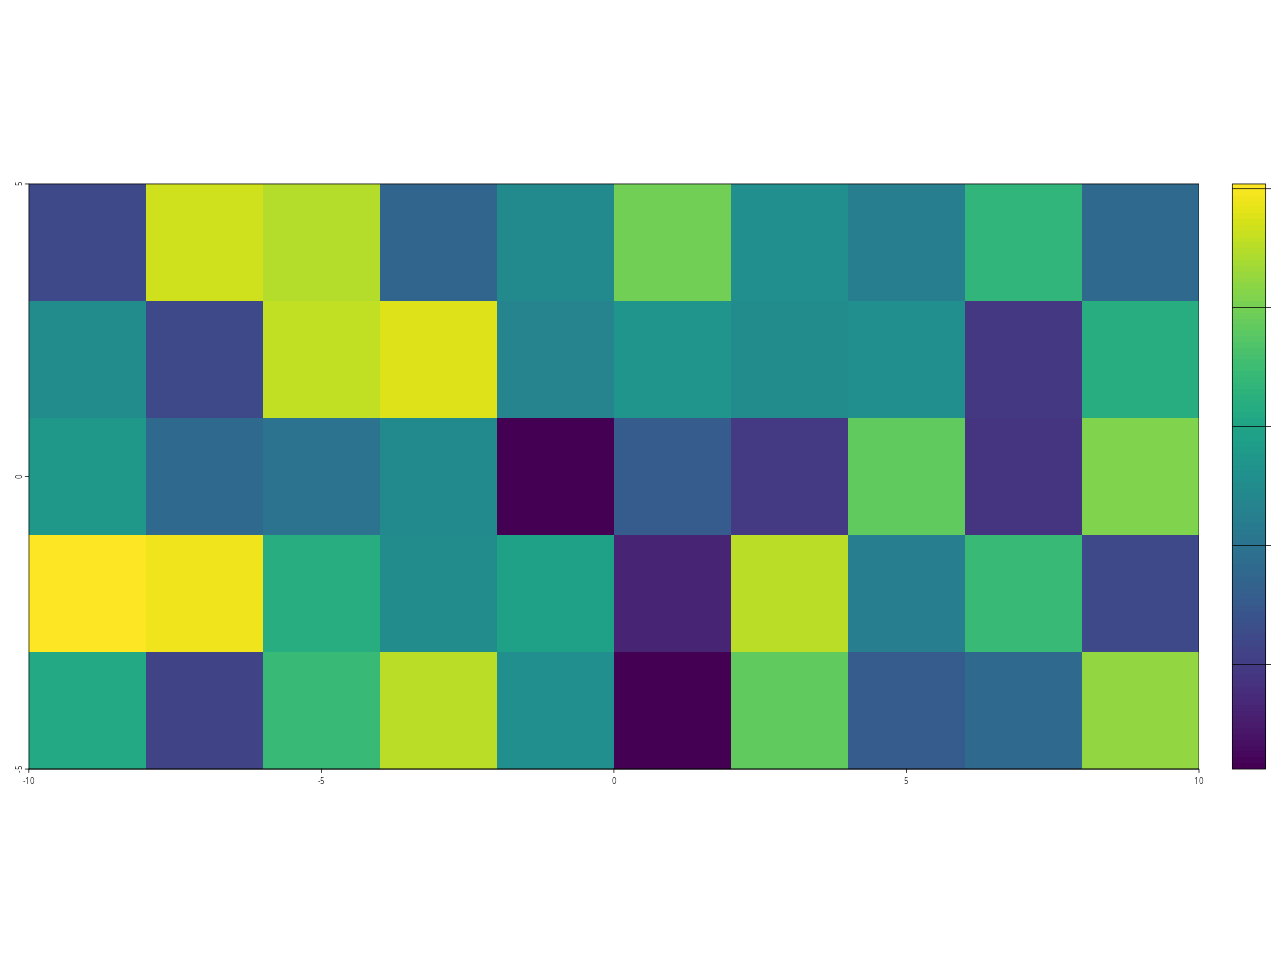

In [23]:
# Example 1

r <- rast(nrows = 5, ncols = 10,
          xmin = -10, xmax = 10,
          ymin = -5, ymax = 5,
          crs = "EPSG:4326",
          vals = matrix(ceiling(255 * runif(50)),
                        nrow = 5, ncol = 10))

plot(r)

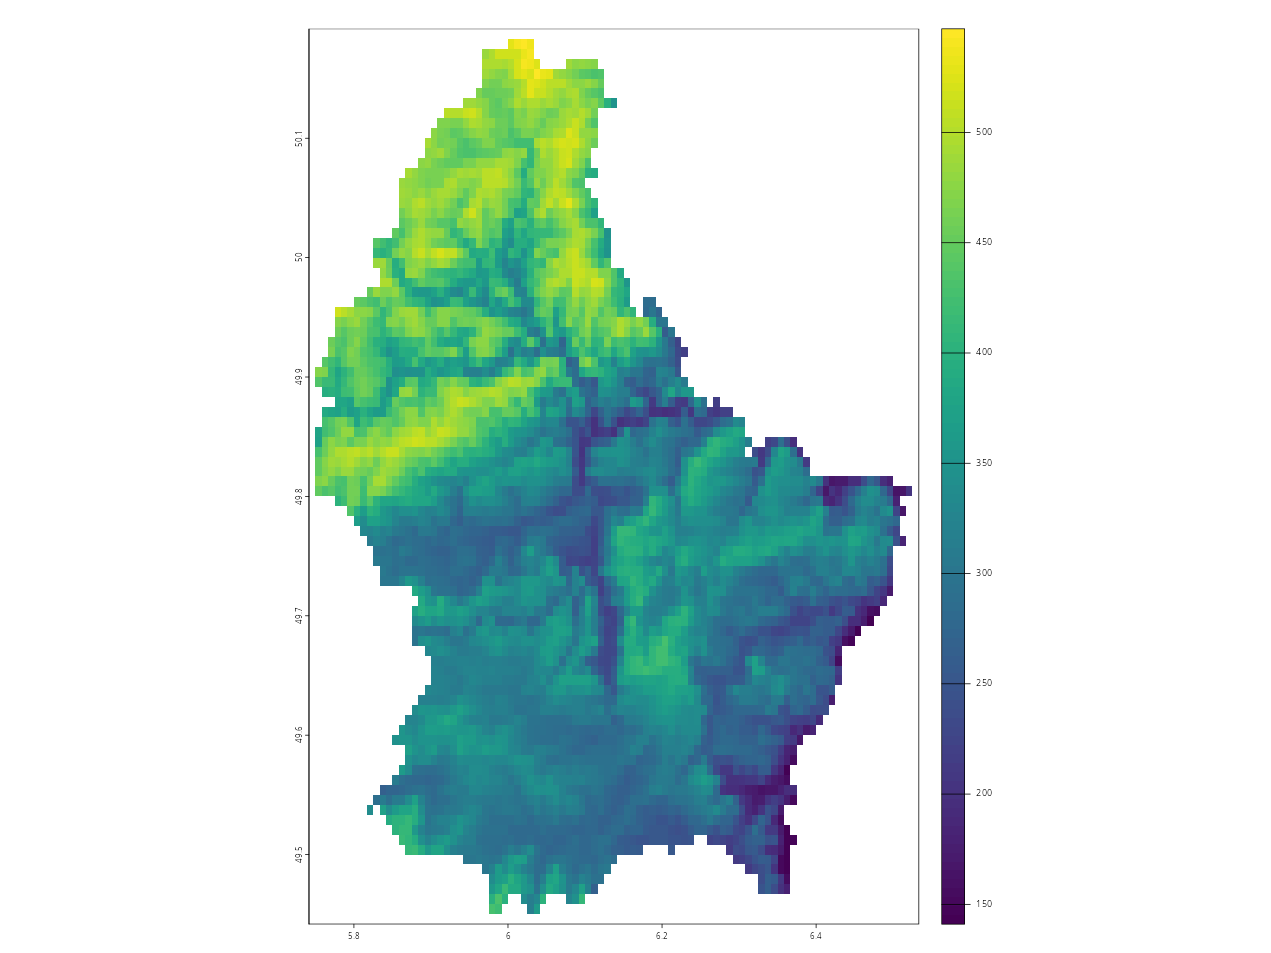

In [ ]:
# Example 2

f <- system.file("ex/elev.tif", package = "terra")
r <- rast(f)

plot(r)

In [ ]:
# Create a skeleton with no associated cell values
rast(s)

# from a matrix 
m <- matrix(1:25, nrow = 5, ncol = 5)
rm <- rast(m)

# from a "xyz" data.frame
d <- as.data.frame(rm, xy = TRUE)
head(d)
rast(d, type = "xyz")

## Rasterize matrix data

Transfer values associated with matrix data to a raster

In [ ]:
# GSTB rasterize matrix
# NaaVRE:
#  cell:
#   inputs:
#    - in_vector: String
#    - in_raster: String
#   params:
#    - param_values: List
#    - param_fun: String
#    - param_background: String
#    - param_group: String
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# Two-column matrix (point coordinates) or data.frame to be rasterized
x <- vect(in_vector, type = "points")
 
# SpatRaster to define spatial characteristics
if(!is.null(in_raster)) {
  y <- rast(in_raster)
}

# Rasterize
rasterize(x          = x,
          y          = y,
          values     = param_values,
          fun        = param_fun,
          background = param_background,
          update     = FALSE,
          by         = param_group,
          filename   = paste0(param_out, "/rasterized_matrix.tif"),
          overwrite  = TRUE)

In [ ]:
# Example

set.seed(1)
x <- spatSample(rast(xmin = 0, ncols = 18, nrows = 18),
                1000, xy = TRUE, replace = TRUE)
y <- rast(xmin = 0, ncols = 18, nrows = 18)

r <- rasterize(x, y, fun = sum)
plot(r)
points(x, col = "red")

## Rasterize vector data

Transfer values associated with the geometries of vector data to a raster

In [ ]:
# GSTB rasterize vector
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - in_vector: String
#    - in_raster: String
#   params:
#    - param_field: String
#    - param_mode: String
#    - param_fun: String
#    - param_touches: Boolean
#    - param_group: String
#    - param_background: String
#    - param_out: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# SpatVector to be rasterized
x <- vect(in_vector)

# SpatRaster to define spatial characteristics
if(!is.null(in_raster)) {
  y <- rast(in_raster)
}

# Rasterization mode
#   "binary" : returns whether a cell is covered by the polygons
#   "fraction" : returns the fraction of a cell that is covered by the polygons
if(mode == "binary") {
  cover <- FALSE
} else if(mode == "fraction") {
  cover <- TRUE
}

# Rasterize
rasterize(x          = x,
          y          = y,
          field      = param_field,
          fun        = param_fun,
          background = param_background,
          touches    = param_touches,
          update     = FALSE,
          cover      = param_mode,
          by         = param_group,
          filename   = paste0(param_out, "/rasterized_vector.tif"),
          overwrite  = TRUE)

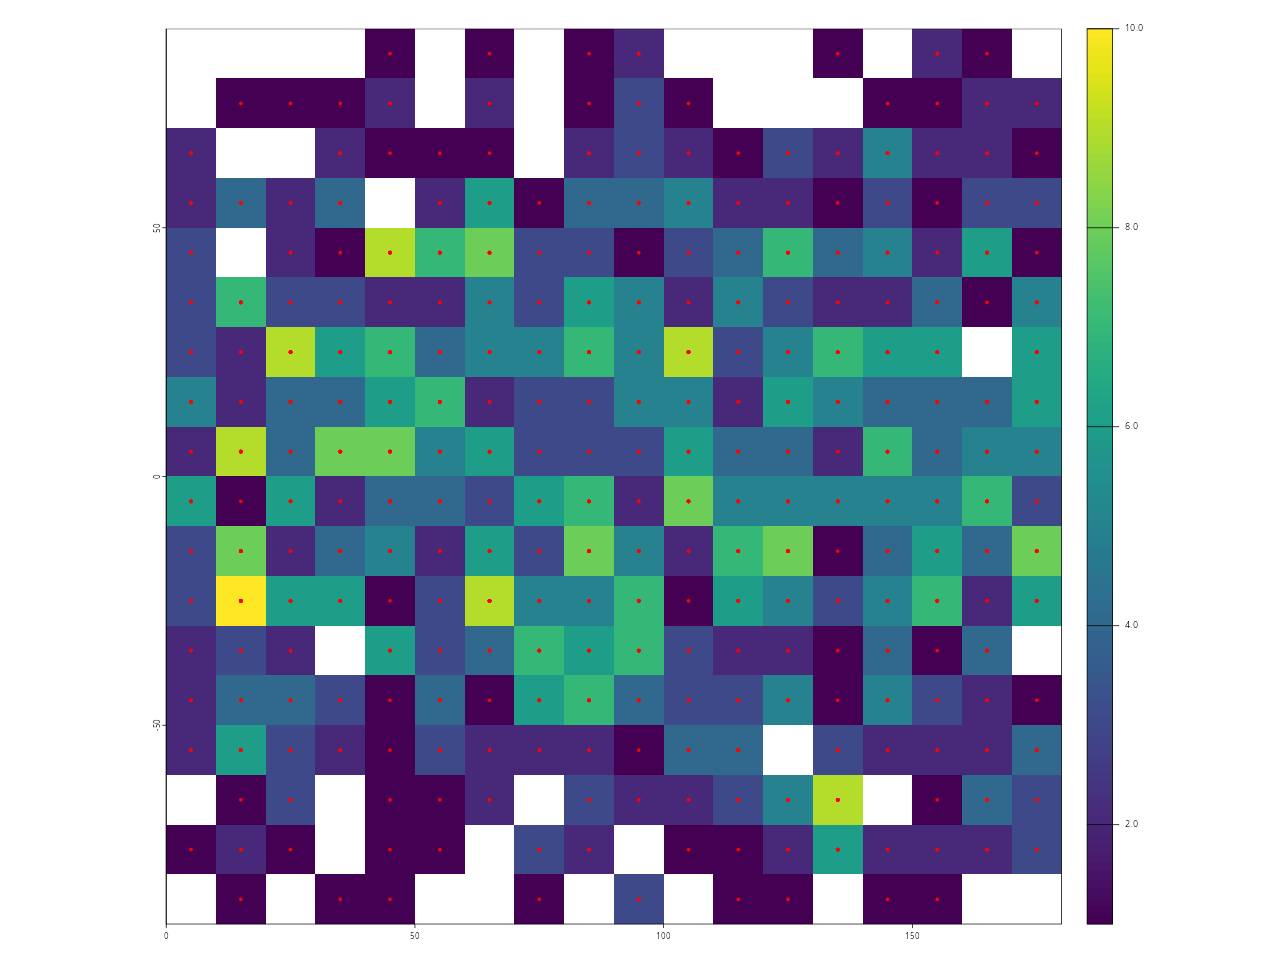

In [14]:
# Example 1

set.seed(1)
x <- spatSample(rast(xmin = 0, ncols = 18, nrows = 18),
                1000, xy = TRUE, replace = TRUE)
y <- rast(xmin = 0, ncols = 18, nrows = 18)

x <- vect(x)
r <- rasterize(x, y, fun = "sum")
plot(r)
points(x, col = "red")

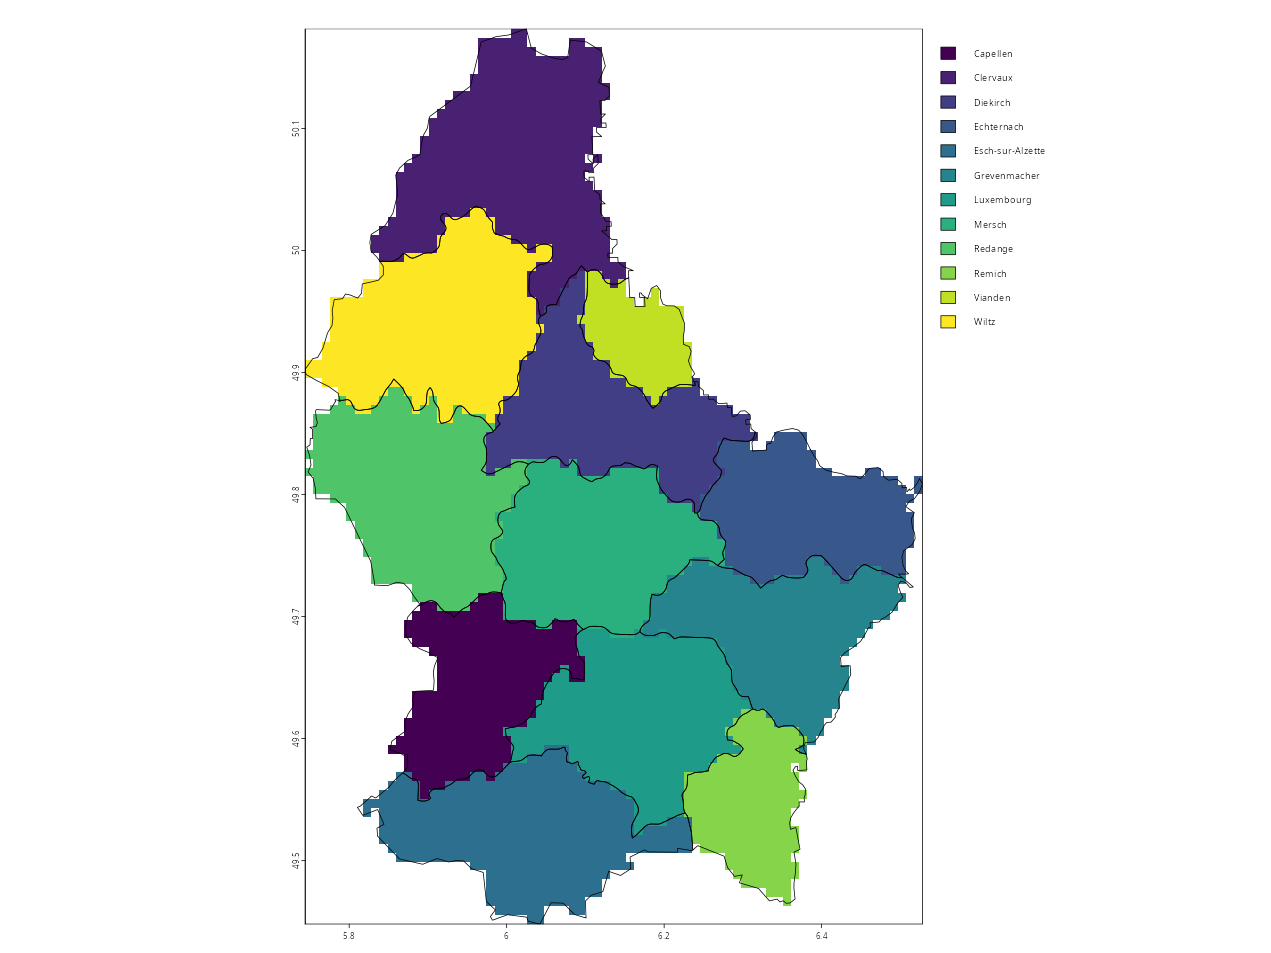

In [ ]:
# Example 2

f <- system.file("ex/lux.shp", package = "terra")
x <- vect(f)
y <- rast(x, ncols = 75, nrows = 100)

r <- rasterize(x, y, "NAME_2")
plot(r)
lines(x)